In [1]:
from checkers import MiniMaxGameBot, GameState, GameNode, new_board
from copy import deepcopy
from math import inf

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
MAX_ROUNDS = 500

In [4]:
def play_game(bot_max_depth: int, bot_mini_depth: int) -> list["GameState"]:
    game = GameState()
    bot_max = MiniMaxGameBot(GameNode(game, 0), bot_max_depth)
    bot_mini = MiniMaxGameBot(GameNode(game, 0), bot_mini_depth)
    history = [deepcopy(game)]
    for i in range(MAX_ROUNDS):
        if i%100 == 0:
            print(f"Processing round {i}...")
        bot = bot_max if game.current_player == "r" else bot_mini
        game = bot.minimax_move(i == 0, game)
        if game is None:
            break
        history.append(deepcopy(game))
        
    return history

In [5]:
history = play_game(1, 6)
print(history[-1])

Processing round 0...
+-curr:r-+
|        |
|        |
| b b   b|
|    b b |
|        |
|  b   B |
|     b  |
|        |
+-|-inf|-+


In [6]:
for state in history[-5:]:
    print(str(state))

+-curr:r-+
|        |
|    b   |
| b b   b|
|b   b r |
|        |
|  r   B |
|     b  |
|        |
+-|-6.5|-+
+-curr:b-+
|        |
|    b   |
| b b   b|
|b   b r |
| r      |
|      B |
|     b  |
|        |
+-|-6.5|-+
+-curr:r-+
|        |
|    b   |
| b b   b|
|    b r |
|        |
|  b   B |
|     b  |
|        |
+-|-7.5|-+
+-curr:b-+
|        |
|    b   |
| b b r b|
|    b   |
|        |
|  b   B |
|     b  |
|        |
+-|-7.5|-+
+-curr:r-+
|        |
|        |
| b b   b|
|    b b |
|        |
|  b   B |
|     b  |
|        |
+-|-inf|-+


In [11]:
games_bck = games

In [27]:
DEPTH=6
History = list[GameState]
games: list[list[History]] = [[play_game(max_depth, mini_depth) for mini_depth in range(1, DEPTH+1)] for max_depth in range(1, DEPTH+1)]

Processing round 0...
Processing round 0...
Processing round 0...
Processing round 0...
Processing round 0...
Processing round 0...
Processing round 0...
Processing round 0...
Processing round 100...
Processing round 200...
Processing round 300...
Processing round 400...
Processing round 0...
Processing round 0...
Processing round 0...
Processing round 0...
Processing round 100...
Processing round 200...
Processing round 300...
Processing round 0...
Processing round 0...
Processing round 0...
Processing round 0...
Processing round 0...
Processing round 0...
Processing round 100...
Processing round 0...
Processing round 0...
Processing round 100...
Processing round 0...
Processing round 100...
Processing round 200...
Processing round 0...
Processing round 100...
Processing round 200...
Processing round 300...
Processing round 400...
Processing round 0...
Processing round 0...
Processing round 100...
Processing round 0...
Processing round 0...
Processing round 0...
Processing round 100..

In [20]:
games_advanced: list[list[dict]] = []
DEPTH = 6
ITERS = 2
for bot_max_d in range(1, DEPTH + 1):
    games_advanced.append([])
    for bot_mini_d in range(1, DEPTH + 1):
        wins_max = 0
        wins_mini = 0
        ties = 0
        for iteration in range(10):
            print(f"{bot_max_d=} {bot_mini_d=} {iteration=}")
            history = play_game(bot_max_d, bot_mini_d)
            if history[-1].score == inf:
                wins_max += 1
            elif history[-1].score == -inf:
                wins_mini += 1
            else:
                ties += 1
        games_advanced[-1].append({
            "wins_max": wins_max,
            "wins_mini": wins_mini,
            "ties": ties
        })

bot_max_d=1 bot_mini_d=1 iteration=0
Processing round 0...
bot_max_d=1 bot_mini_d=1 iteration=1
Processing round 0...
bot_max_d=1 bot_mini_d=1 iteration=2
Processing round 0...
bot_max_d=1 bot_mini_d=1 iteration=3
Processing round 0...
bot_max_d=1 bot_mini_d=1 iteration=4
Processing round 0...
bot_max_d=1 bot_mini_d=1 iteration=5
Processing round 0...
bot_max_d=1 bot_mini_d=1 iteration=6
Processing round 0...
bot_max_d=1 bot_mini_d=1 iteration=7
Processing round 0...
bot_max_d=1 bot_mini_d=1 iteration=8
Processing round 0...
bot_max_d=1 bot_mini_d=1 iteration=9
Processing round 0...
bot_max_d=1 bot_mini_d=2 iteration=0
Processing round 0...
bot_max_d=1 bot_mini_d=2 iteration=1
Processing round 0...
bot_max_d=1 bot_mini_d=2 iteration=2
Processing round 0...
bot_max_d=1 bot_mini_d=2 iteration=3
Processing round 0...
bot_max_d=1 bot_mini_d=2 iteration=4
Processing round 0...
bot_max_d=1 bot_mini_d=2 iteration=5
Processing round 0...
bot_max_d=1 bot_mini_d=2 iteration=6
Processing round 0.

In [21]:
def set_depth_ticks(ax, n_mini, n_max):
    ax.set_xticks(range(n_max), labels=[str(d) for d in range(1, n_max + 1)])
    ax.set_yticks(range(n_mini), labels=[str(d) for d in range(1, n_mini + 1)])
    ax.set_xlabel("max depth")
    ax.set_ylabel("mini depth")


def plot_three_heatmaps(grid, total=10):
    keys = ["wins_max", "wins_mini", "ties"]
    mats = {k: np.array([[cell[k] for cell in row] for row in grid], dtype=float)/total for k in keys}
    n_mini, n_max = mats[keys[0]].shape

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
    for ax, k in zip(axes, keys):
        im = ax.imshow(mats[k], vmin=0, vmax=1, cmap="RdYlGn", origin="upper")
        ax.set_title(k)
        ax.set_xlabel("max depth")
        ax.set_ylabel("mini depth")
        set_depth_ticks(ax, n_mini, n_max)
        fig.colorbar(im, ax=ax, fraction=0.046)
        for i in range(mats[k].shape[0]):
            for j in range(mats[k].shape[1]):
                ax.text(j, i, f"{mats[k][i,j]*total:.0f}", ha="center", va="center", color="black")
    return fig

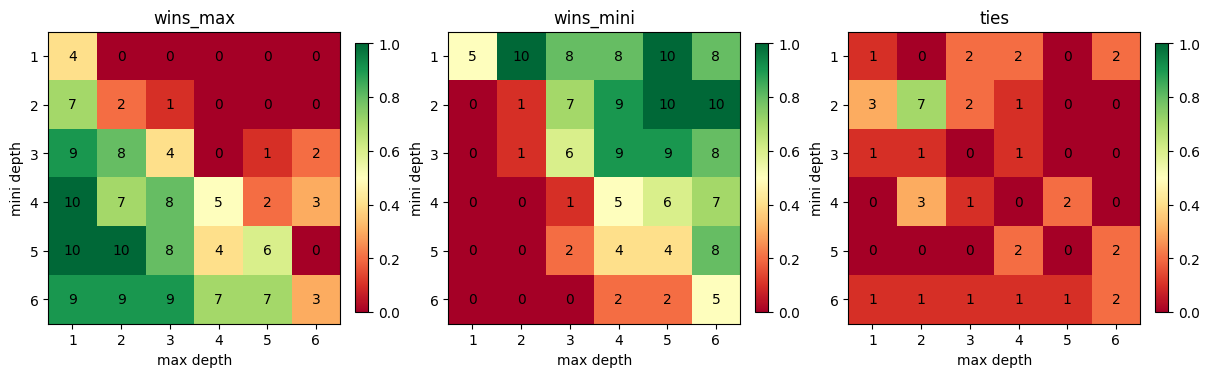

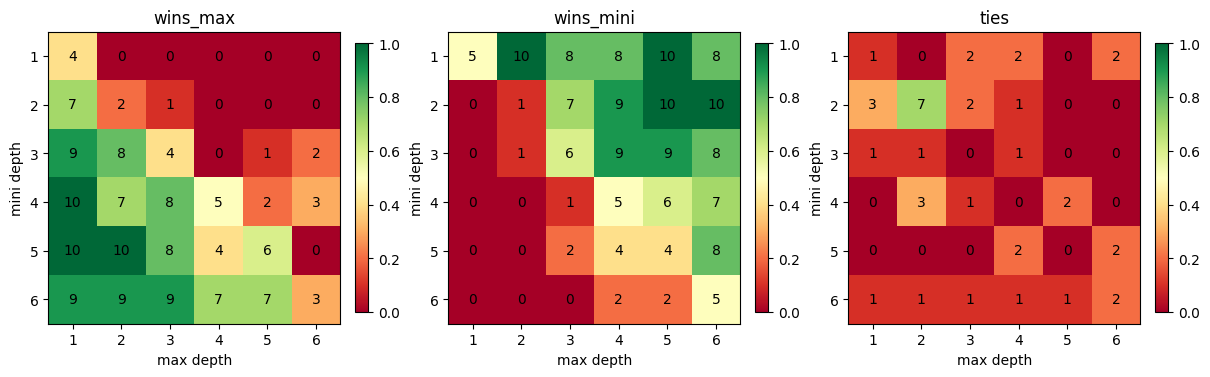

In [22]:
plot_three_heatmaps(games_advanced)

In [13]:
games_final_scores = [[history[-1].score for history in row] for row in games]
print(*games_final_scores, sep='\n')

[inf, -inf, -inf, -inf, -inf, -inf]
[inf, 1.5, -inf, -10.5, -inf, -inf]
[inf, inf, inf, -inf, -inf, inf]
[inf, inf, inf, inf, -inf, -inf]
[inf, inf, inf, inf, -inf, -inf]
[11.0, inf, inf, inf, inf, inf]


In [14]:
game1 = [g.score for g in games[1][5]]
game2 = [g.score for g in games[3][3]]
game3 = [g.score for g in games[5][1]]

In [14]:
from matplotlib.lines import Line2D

In [25]:
def show_games(games: dict[str, list[float]]):
    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
    for label, y in games.items():
        ax.plot(range(1, len(y) + 1), y, lw=1.8, label=label)
    ax.set_title("3 example gameplays with different depth configurations")
    ax.axhline(0, color="0.5", lw=1, alpha=0.6)
    ax.set(xlabel="move", ylabel="score (r + / b -)", xlim=(1, max(map(len, games.values()))))
    ax.grid(True, alpha=0.25)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    return fig


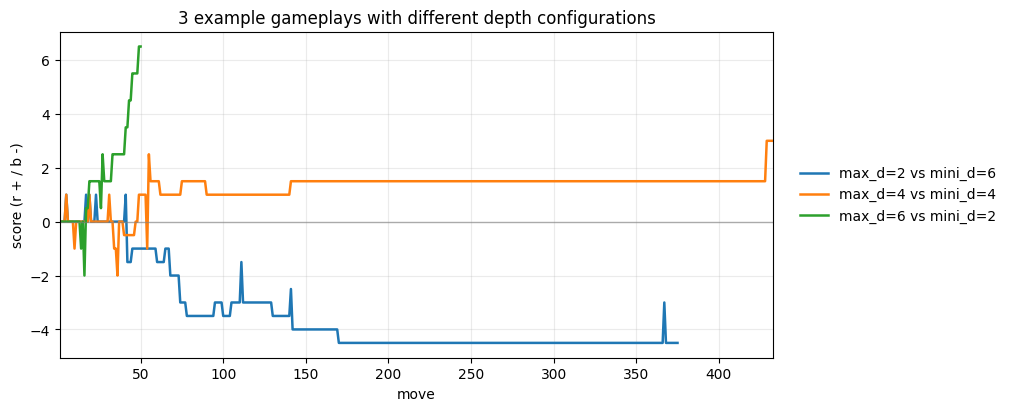

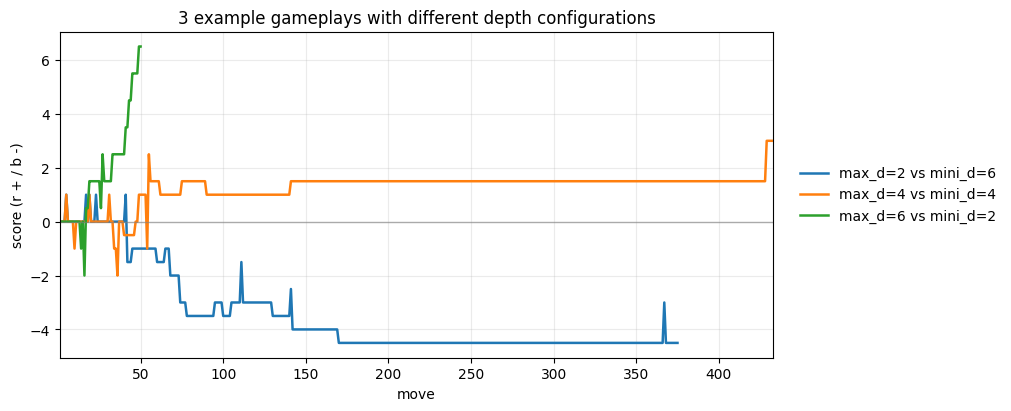

In [28]:
show_games({
    "max_d=2 vs mini_d=6": [g.score for g in games[1][5]],
    "max_d=4 vs mini_d=4": [g.score for g in games[3][3]],
    "max_d=6 vs mini_d=2": [g.score for g in games[5][1]]
})

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def plot_final_scores(final_scores: list[list[float]]) -> None:
    A = np.asarray(final_scores, dtype=float)
    n_rows, n_cols = A.shape

    finite = A[np.isfinite(A)]
    v = float(np.max(np.abs(finite))) if finite.size else 1.0
    v = 1.0 if v == 0 else v
    A_c = np.clip(A, -v, v)
    norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)

    fig, ax = plt.subplots(figsize=(0.9 * n_cols + 2.0, 0.9 * n_rows + 1.5))
    im = ax.imshow(A_c, cmap="RdBu_r", norm=norm, origin="upper")

    cbar = fig.colorbar(im, ax=ax, pad=0.02, shrink=0.9)
    cbar.set_label("Final score (r + / b -)  [clipped for color]")

    ax.set_title("MiniMax vs MiniMax — Final scores")
    ax.set_xlabel("b depth")
    ax.set_ylabel("r depth")
    ax.set_xticks(range(n_cols), labels=[str(j + 1) for j in range(n_cols)])
    ax.set_yticks(range(n_rows), labels=[str(i + 1) for i in range(n_rows)])

    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    for i in range(n_rows):
        for j in range(n_cols):
            val = A[i, j]
            if np.isposinf(val):
                txt = "r win"
            elif np.isneginf(val):
                txt = "b win"
            else:
                txt = f"{val:.1f}"


            text_color = "white" if abs(A_c[i, j]) > 0.6 * v else "black"
            ax.text(j, i, txt, ha="center", va="center", fontsize=9, color=text_color)

    fig.tight_layout()

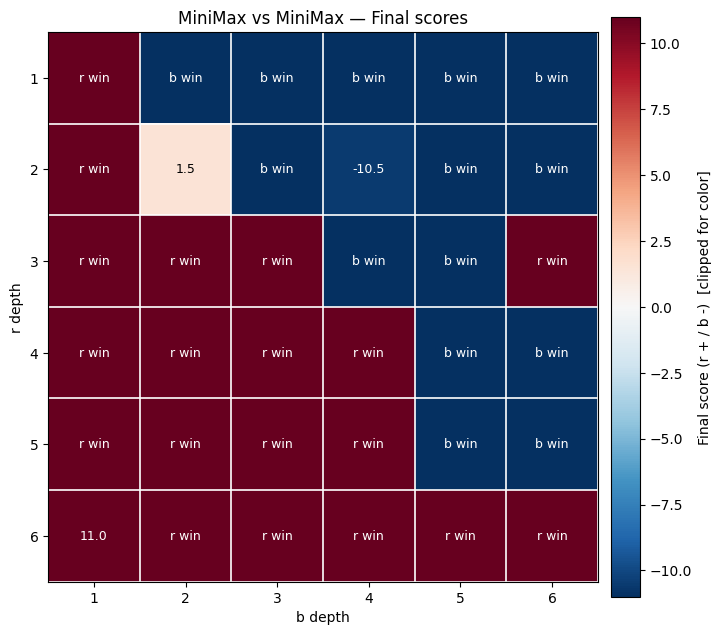

In [18]:
plot_final_scores(games_final_scores)

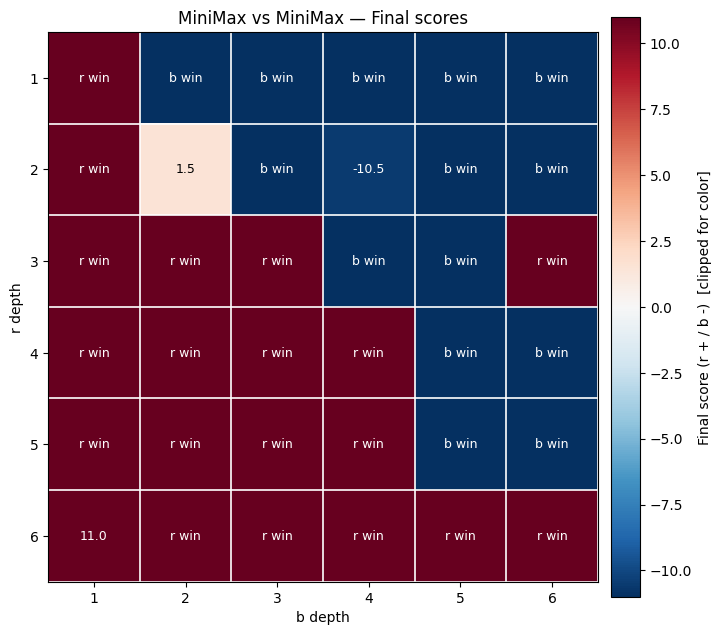

In [19]:
plot_final_scores(games_final_scores)